# Optimización de un controlador PID mediante PSO
## Péndulo invertido de un robot balanceador real

**Materia**: Algoritmos Evolutivos I (2026) — Desafío Práctico
**Repositorio**: https://github.com/piertotumlocomotor/robot_balance (rama `develop`)

Todos los parámetros físicos salen de mediciones directas sobre el robot real (no asumidos). Discusión completa, deducciones y registro de mediciones: `informes/borrador_entrega.md` (o `entrega_pso_pendulo.pdf`).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

## 1. Modelo del sistema

```
theta'' = OMEGA0^2 * theta + K_U_efectivo(u) * u_efectivo
```

In [2]:
# --- Parametros medidos en el robot real (ver informe, seccion 4) ---
OMEGA0 = 7.4        # rad/s
MAX_DUTY = 160      # cap de seguridad de PWM en modo brake

# Zona muerta por motor (asimetria medida con balanza)
DEAD_ZONE_M1 = 92.0
DEAD_ZONE_M2 = 102.0
PROP_M1 = 0.575     # fraccion de K_U que aporta M1 solo, entre las dos zonas muertas

K_U = 0.0218        # rad/s^2 por unidad de duty, medido con balanza

# --- Parametros de la simulacion ---
CONTROL_DT = 0.01          # 100 Hz
PHYSICS_SUBSTEPS = 10      # sub-pasos de fisica por muestra de control (evita artefactos numericos)
PHYSICS_DT = CONTROL_DT / PHYSICS_SUBSTEPS
N_FILTRO_D = 0.08          # constante de tiempo del filtro pasa-bajos sobre la derivada, s

SIM_TIME = 4.0
THETA0 = np.radians(2.0)           # perturbacion de referencia (media real medida)
ANGULO_CAIDA = np.radians(60.0)    # corte de integracion, no el criterio de penalizacion (30°, ver costo())

In [3]:
def aplicar_actuador_real(u):
    """Satura al cap de seguridad; la zona muerta la aplica k_u_efectivo."""
    return np.clip(u, -MAX_DUTY, MAX_DUTY)


def k_u_efectivo(u_abs):
    """Fraccion de K_U disponible segun cuantos motores superaron su zona muerta."""
    if u_abs < DEAD_ZONE_M1:
        return 0.0
    elif u_abs < DEAD_ZONE_M2:
        return PROP_M1
    else:
        return 1.0


def simular_pendulo(kp, ki, kd, theta0=THETA0, theta_dot0=0.0, t_total=SIM_TIME):
    """Simula el pendulo invertido linealizado bajo control PID, con zona
    muerta por motor y cap de PWM reales. Fisica en sub-pasos + derivada
    filtrada (evita artefactos numericos de Euler/derivada cruda a 100 Hz)."""
    n = int(t_total / CONTROL_DT)
    theta = theta0
    theta_dot = theta_dot0
    integral = 0.0
    error_previo = theta0
    deriv_filtrada = 0.0
    alpha = CONTROL_DT / (N_FILTRO_D + CONTROL_DT)

    t_hist = np.zeros(n)
    theta_hist = np.zeros(n)
    u_hist = np.zeros(n)

    for i in range(n):
        error = theta
        integral += error * CONTROL_DT
        derivada_cruda = (error - error_previo) / CONTROL_DT
        deriv_filtrada += alpha * (derivada_cruda - deriv_filtrada)
        error_previo = error

        u_pid = kp * error + ki * integral + kd * deriv_filtrada
        u_motor = -u_pid
        u_efectivo = aplicar_actuador_real(u_motor)

        for _ in range(PHYSICS_SUBSTEPS):
            theta_ddot = OMEGA0**2 * theta + K_U * k_u_efectivo(abs(u_efectivo)) * u_efectivo
            theta_dot += theta_ddot * PHYSICS_DT
            theta += theta_dot * PHYSICS_DT

        t_hist[i] = i * CONTROL_DT
        theta_hist[i] = theta
        u_hist[i] = u_efectivo

        if abs(theta) > ANGULO_CAIDA:
            theta_hist[i:] = theta
            u_hist[i:] = u_efectivo
            break

    return t_hist, theta_hist, u_hist

## 2. Función de costo

ITAE promedio sobre 9 escenarios (3 ángulos × 3 velocidades iniciales, rango real medido), con penalización si el péndulo termina caído.

In [4]:
# Angulos: rango real medido (media 1.98°, peor caso 3.06°, n=22).
# Velocidades: acotadas por el umbral de "quietud" (0.15 rad/s) del mismo metodo de medicion.
ESCENARIOS = [
    (np.radians(a), v)
    for a in (1.5, 2.0, 3.0)
    for v in (-0.15, 0.0, 0.15)
]


def costo(kp, ki, kd):
    """ITAE promedio sobre todos los escenarios, con penalizacion si el pendulo cae."""
    if kp < 0 or ki < 0 or kd < 0:
        return 1e6

    total = 0.0
    for theta0, theta_dot0 in ESCENARIOS:
        t_hist, theta_hist, _ = simular_pendulo(kp, ki, kd, theta0=theta0, theta_dot0=theta_dot0)
        itae = np.sum(t_hist * np.abs(theta_hist)) * CONTROL_DT
        penalizacion = 500.0 if abs(theta_hist[-1]) > np.radians(30) else 0.0
        total += itae + penalizacion

    return total / len(ESCENARIOS)

## 3. PSO (implementado desde cero, constricción de Clerc-Kennedy)

In [5]:
def pso_optimizar(n_particulas=25, n_generaciones=40, semilla=7, verbose=True):
    rng = np.random.default_rng(semilla)

    lim_inf = np.array([0.0, 0.0, 0.0])
    lim_sup = np.array([3500.0, 3000.0, 800.0])  # limites de busqueda, ver informe seccion 4.4

    phi1, phi2 = 2.05, 2.05
    phi = phi1 + phi2
    chi = 2 / abs(2 - phi - np.sqrt(phi**2 - 4 * phi))

    posiciones = rng.uniform(lim_inf, lim_sup, size=(n_particulas, 3))
    velocidades = rng.uniform(-1, 1, size=(n_particulas, 3)) * (lim_sup - lim_inf) * 0.1

    costos = np.array([costo(*p) for p in posiciones])
    pbest_pos = posiciones.copy()
    pbest_costo = costos.copy()
    gbest_idx = np.argmin(pbest_costo)
    gbest_pos = pbest_pos[gbest_idx].copy()
    gbest_costo = pbest_costo[gbest_idx]

    historial = [gbest_costo]

    for gen in range(n_generaciones):
        r1 = rng.uniform(0, 1, size=(n_particulas, 3))
        r2 = rng.uniform(0, 1, size=(n_particulas, 3))

        velocidades = chi * (
            velocidades
            + phi1 * r1 * (pbest_pos - posiciones)
            + phi2 * r2 * (gbest_pos - posiciones)
        )
        posiciones = np.clip(posiciones + velocidades, lim_inf, lim_sup)

        costos = np.array([costo(*p) for p in posiciones])

        mejora = costos < pbest_costo
        pbest_pos[mejora] = posiciones[mejora]
        pbest_costo[mejora] = costos[mejora]

        gen_mejor_idx = np.argmin(pbest_costo)
        if pbest_costo[gen_mejor_idx] < gbest_costo:
            gbest_costo = pbest_costo[gen_mejor_idx]
            gbest_pos = pbest_pos[gen_mejor_idx].copy()

        historial.append(gbest_costo)
        if verbose and (gen + 1) % 5 == 0:
            print(f"Generacion {gen+1:3d}/{n_generaciones}  costo gbest = {gbest_costo:.4f}")

    return gbest_pos, gbest_costo, historial

In [6]:
mejores_ganancias, mejor_costo, convergencia = pso_optimizar()
kp_opt, ki_opt, kd_opt = mejores_ganancias

print()
print(f"Kp = {kp_opt:.2f}")
print(f"Ki = {ki_opt:.2f}")
print(f"Kd = {kd_opt:.2f}")
print(f"Costo final: {mejor_costo:.4f}")

# Chequeo de sanidad: ¿alguna ganancia quedo pegada al limite de busqueda?
LIM_SUP = np.array([3500.0, 3000.0, 800.0])
for nombre, valor, lim in zip(("Kp", "Ki", "Kd"), mejores_ganancias, LIM_SUP):
    if valor >= 0.99 * lim:
        print(f"  [!] {nombre} quedo en el limite superior ({lim:.0f}) - ver informe, seccion 4.5")

Generacion   5/40  costo gbest = 55.6007
Generacion  10/40  costo gbest = 55.5973
Generacion  15/40  costo gbest = 55.5973
Generacion  20/40  costo gbest = 55.5973
Generacion  25/40  costo gbest = 55.5973
Generacion  30/40  costo gbest = 55.5973
Generacion  35/40  costo gbest = 55.5973
Generacion  40/40  costo gbest = 55.5973

Kp = 3500.00
Ki = 2297.02
Kd = 484.22
Costo final: 55.5973
  [!] Kp quedo en el limite superior (3500) - ver informe, seccion 4.5


In [7]:
# Verificacion escenario por escenario (el costo promediado no muestra fallos puntuales)
print("theta0(deg)  theta_dot0(rad/s)   theta_final(deg)   max|theta|(deg)   ITAE      ¿cayo?")
algun_fallo = False
suma_total = 0.0
for theta0, theta_dot0 in ESCENARIOS:
    t_hist, theta_hist, _ = simular_pendulo(kp_opt, ki_opt, kd_opt, theta0=theta0, theta_dot0=theta_dot0)
    itae = np.sum(t_hist * np.abs(theta_hist)) * CONTROL_DT
    cayo = np.degrees(np.max(np.abs(theta_hist))) > 30
    penalizacion = 500.0 if abs(theta_hist[-1]) > np.radians(30) else 0.0
    suma_total += itae + penalizacion
    algun_fallo = algun_fallo or cayo
    print(f"{np.degrees(theta0):11.2f}  {theta_dot0:+17.2f}   {np.degrees(theta_hist[-1]):15.3f}   "
          f"{np.degrees(np.max(np.abs(theta_hist))):15.3f}   {itae:7.4f}   {'SI' if cayo else 'no'}")

print("\n" + ("[!] Al menos un escenario cae con estas ganancias." if algun_fallo
              else "OK: ningun escenario de diseño cae con estas ganancias."))
print(f"\nSuma total / {len(ESCENARIOS)} = {suma_total/len(ESCENARIOS):.4f}  "
      f"(coincide con el costo final de gbest: {mejor_costo:.4f})")

theta0(deg)  theta_dot0(rad/s)   theta_final(deg)   max|theta|(deg)   ITAE      ¿cayo?
       1.50              -0.15            -0.079             1.415    0.0406   no
       1.50              +0.00             0.109             1.560    0.0370   no
       1.50              +0.15            -0.240             2.129    0.0350   no
       2.00              -0.15             0.080             1.912    0.0373   no
       2.00              +0.00            -0.245             1.998    0.0359   no
       2.00              +0.15             0.018             2.590    0.0321   no
       3.00              -0.15            -0.356             2.912    0.0334   no
       3.00              +0.00             0.095             2.998    0.0261   no
       3.00              +0.15            60.158            60.158    0.0981   SI

[!] Al menos un escenario cae con estas ganancias.

Suma total / 9 = 55.5973  (coincide con el costo final de gbest: 55.5973)


## 4. Gráfico de convergencia

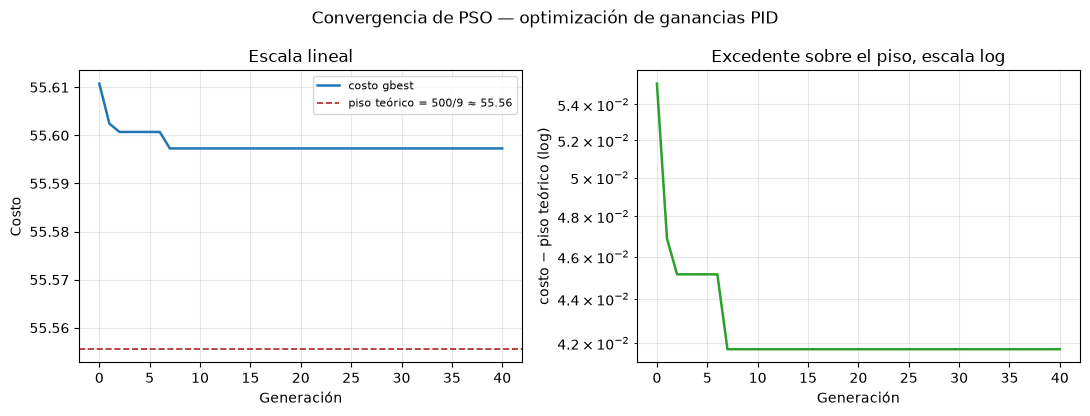

Piso teorico (500/9):        55.5556
Costo final encontrado:            55.5973
Distancia al piso:                 0.0417  (0.075% por encima)


In [8]:
piso_teorico = 500.0 / len(ESCENARIOS)  # cota inferior: el escenario 9 no se puede evitar (informe 4.6)
excedente = np.array(convergencia) - piso_teorico  # distancia al piso, > 0 siempre

fig, axs = plt.subplots(1, 2, figsize=(11, 4.2))

axs[0].plot(convergencia, linewidth=1.8, label="costo gbest")
axs[0].axhline(piso_teorico, color="firebrick", linestyle="--", linewidth=1.2,
                label=f"piso teórico = 500/{len(ESCENARIOS)} ≈ {piso_teorico:.2f}")
axs[0].set_xlabel("Generación")
axs[0].set_ylabel("Costo")
axs[0].set_title("Escala lineal")
axs[0].legend(fontsize=8)
axs[0].grid(alpha=0.3)

axs[1].semilogy(excedente, linewidth=1.8, color="tab:green")
axs[1].set_xlabel("Generación")
axs[1].set_ylabel("costo − piso teórico (log)")
axs[1].set_title("Excedente sobre el piso, escala log")
axs[1].grid(alpha=0.3, which="both")

fig.suptitle("Convergencia de PSO — optimización de ganancias PID")
plt.tight_layout()
plt.savefig("convergencia_pso.png", dpi=150)
plt.show()

print(f"Piso teorico (500/{len(ESCENARIOS)}):        {piso_teorico:.4f}")
print(f"Costo final encontrado:            {mejor_costo:.4f}")
print(f"Distancia al piso:                 {mejor_costo - piso_teorico:.4f}  ({100*(mejor_costo-piso_teorico)/piso_teorico:.3f}% por encima)")

### 4.1 Convergencia del enjambre (no solo el costo)

Verificacion: mismo resultado que pso_optimizar() -> costo=55.5973  (oficial: 55.5973)


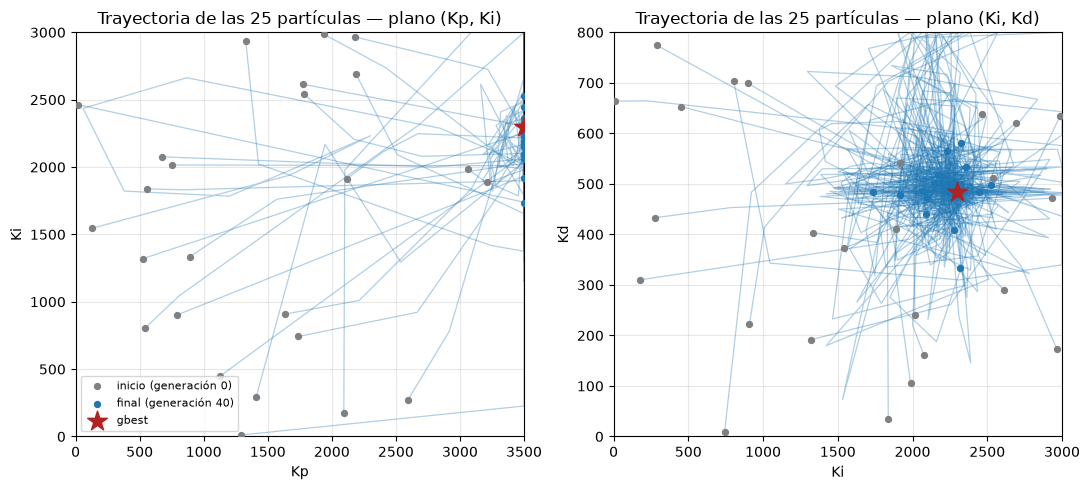

In [9]:
def pso_optimizar_con_historial(n_particulas=25, n_generaciones=40, semilla=7):
    """Copia instrumentada de pso_optimizar que ademas guarda la posicion de
    las 25 particulas por generacion, solo para graficar (no cambia el resultado)."""
    rng = np.random.default_rng(semilla)
    lim_inf = np.array([0.0, 0.0, 0.0])
    lim_sup = np.array([3500.0, 3000.0, 800.0])
    phi1, phi2 = 2.05, 2.05
    phi = phi1 + phi2
    chi = 2 / abs(2 - phi - np.sqrt(phi**2 - 4 * phi))

    posiciones = rng.uniform(lim_inf, lim_sup, size=(n_particulas, 3))
    velocidades = rng.uniform(-1, 1, size=(n_particulas, 3)) * (lim_sup - lim_inf) * 0.1

    costos = np.array([costo(*p) for p in posiciones])
    pbest_pos = posiciones.copy()
    pbest_costo = costos.copy()
    gbest_idx = np.argmin(pbest_costo)
    gbest_pos = pbest_pos[gbest_idx].copy()
    gbest_costo = pbest_costo[gbest_idx]

    historial_posiciones = [posiciones.copy()]

    for gen in range(n_generaciones):
        r1 = rng.uniform(0, 1, size=(n_particulas, 3))
        r2 = rng.uniform(0, 1, size=(n_particulas, 3))
        velocidades = chi * (
            velocidades
            + phi1 * r1 * (pbest_pos - posiciones)
            + phi2 * r2 * (gbest_pos - posiciones)
        )
        posiciones = np.clip(posiciones + velocidades, lim_inf, lim_sup)
        costos = np.array([costo(*p) for p in posiciones])
        mejora = costos < pbest_costo
        pbest_pos[mejora] = posiciones[mejora]
        pbest_costo[mejora] = costos[mejora]
        gen_mejor_idx = np.argmin(pbest_costo)
        if pbest_costo[gen_mejor_idx] < gbest_costo:
            gbest_costo = pbest_costo[gen_mejor_idx]
            gbest_pos = pbest_pos[gen_mejor_idx].copy()
        historial_posiciones.append(posiciones.copy())

    return gbest_pos, gbest_costo, np.array(historial_posiciones)


gbest_hist, costo_hist, historial_posiciones = pso_optimizar_con_historial()
print(f"Verificacion: mismo resultado que pso_optimizar() -> costo={costo_hist:.4f}  "
      f"(oficial: {mejor_costo:.4f})")

fig, axs = plt.subplots(1, 2, figsize=(11, 5))

for p in range(historial_posiciones.shape[1]):
    axs[0].plot(historial_posiciones[:, p, 0], historial_posiciones[:, p, 1],
                color="tab:blue", alpha=0.35, linewidth=0.9)
    axs[1].plot(historial_posiciones[:, p, 1], historial_posiciones[:, p, 2],
                color="tab:blue", alpha=0.35, linewidth=0.9)

axs[0].scatter(historial_posiciones[0, :, 0], historial_posiciones[0, :, 1],
               color="gray", s=18, label="inicio (generación 0)", zorder=3)
axs[0].scatter(historial_posiciones[-1, :, 0], historial_posiciones[-1, :, 1],
               color="tab:blue", s=18, label="final (generación 40)", zorder=3)
axs[0].scatter([gbest_hist[0]], [gbest_hist[1]], color="firebrick", marker="*", s=220,
               label="gbest", zorder=4)
axs[0].set_xlim(0, 3500)
axs[0].set_ylim(0, 3000)
axs[0].set_xlabel("Kp")
axs[0].set_ylabel("Ki")
axs[0].set_title("Trayectoria de las 25 partículas — plano (Kp, Ki)")
axs[0].legend(fontsize=8)
axs[0].grid(alpha=0.3)

axs[1].scatter(historial_posiciones[0, :, 1], historial_posiciones[0, :, 2],
               color="gray", s=18, zorder=3)
axs[1].scatter(historial_posiciones[-1, :, 1], historial_posiciones[-1, :, 2],
               color="tab:blue", s=18, zorder=3)
axs[1].scatter([gbest_hist[1]], [gbest_hist[2]], color="firebrick", marker="*", s=220, zorder=4)
axs[1].set_xlim(0, 3000)
axs[1].set_ylim(0, 800)
axs[1].set_xlabel("Ki")
axs[1].set_ylabel("Kd")
axs[1].set_title("Trayectoria de las 25 partículas — plano (Ki, Kd)")
axs[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("convergencia_enjambre.png", dpi=150)
plt.show()

## 5. Validación: respuesta del sistema con las ganancias óptimas

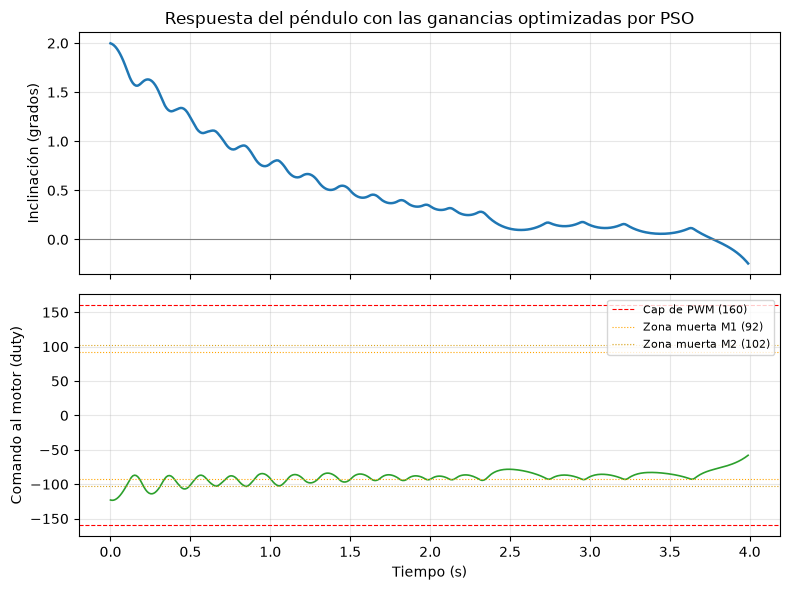

In [10]:
t_hist, theta_hist, u_hist = simular_pendulo(kp_opt, ki_opt, kd_opt)

fig, axs = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

axs[0].plot(t_hist, np.degrees(theta_hist), linewidth=1.8)
axs[0].axhline(0, color="gray", linewidth=0.8)
axs[0].set_ylabel("Inclinación (grados)")
axs[0].set_title("Respuesta del péndulo con las ganancias optimizadas por PSO")
axs[0].grid(alpha=0.3)

axs[1].plot(t_hist, u_hist, linewidth=1.2, color="tab:green")
axs[1].axhline(MAX_DUTY, color="red", linestyle="--", linewidth=0.8, label="Cap de PWM (160)")
axs[1].axhline(-MAX_DUTY, color="red", linestyle="--", linewidth=0.8)
axs[1].axhline(DEAD_ZONE_M1, color="orange", linestyle=":", linewidth=0.8, label="Zona muerta M1 (92)")
axs[1].axhline(-DEAD_ZONE_M1, color="orange", linestyle=":", linewidth=0.8)
axs[1].axhline(DEAD_ZONE_M2, color="goldenrod", linestyle=":", linewidth=0.8, label="Zona muerta M2 (102)")
axs[1].axhline(-DEAD_ZONE_M2, color="goldenrod", linestyle=":", linewidth=0.8)
axs[1].set_ylabel("Comando al motor (duty)")
axs[1].set_xlabel("Tiempo (s)")
axs[1].legend(fontsize=8, loc="upper right")
axs[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("respuesta_pid_optimo.png", dpi=150)
plt.show()

---
Discusión completa (inconvenientes, mediciones, conclusiones): `informes/borrador_entrega.md`.